# Fit nonlinear function to network performance

This script takes in the results from data-overview.ipynb, and performs a regression to extract the impact of different regulatory parameters on the data.

In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.backends.backend_pdf import PdfPages

import matplotlib as mpl
import matplotlib.ticker as ticker

import numpy as np
import pandas as pd
import os
import plotly.graph_objects as go
import plotly.express as px
import pickle
import time

# import clustering packages
from sklearn.linear_model import LinearRegression
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import DotProduct, WhiteKernel
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.optimize import curve_fit
from scipy.interpolate import UnivariateSpline, interp1d
from scipy.signal import savgol_filter

plt.style.use('custom.mplstyle')
%config InlineBackend.figure_format = 'retina'
from tqdm import tqdm
from joblib import Parallel, delayed

from stoch_sim_model import *

In [2]:
# Load data from 2nd infections
reg_model = ''
runs = '-3-'
comment = "acute_all-sparse-reg"
d = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/fits/'
d_mean = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/processed_full_data'+runs+'runs'+'-'+comment+'.pkl'
# d_mean = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/processed_data'+runs+'runs'+'-'+comment+'.pkl'

# Import datasets
clustered_mean_df = pd.read_pickle(d_mean)
# '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/list_processed_data'+runs+'runs'+'-'+comment+'.pkl'
with open('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/list_processed_full_data'+runs+'runs'+'-'+comment+'.pkl', 'rb') as f:
    infection_scenarios = pickle.load(f)

with pd.option_context('display.max_columns', None):
    display(clustered_mean_df)

,b_I,d_I,K_I,I_0,S_0,N_0,d_S,K_H,psi_myc_I,psi_myc_HI,psi_myc_HE,L0_Na,psi_NE_I,psi_NE_HI,psi_NE_HE,L0_NE,psi_EM_I,psi_EM_HI,psi_EM_HE,L0_EM,psi_Edie_I,psi_Edie_HI,psi_Edie_HE,L0_Edie,harm_pI,harm_pS,max_eM_fold,frac_cM,log_T_pEcyteM,T_min_pI,T_max_pI,T_pE_start,T_pE_clear,stim_pI,stim_pHI,stim_pHE,scaled_min_pS,antigenicity_over_harm,harm_pI_noprotection,peff_clearance,peff_toxicity
0,1.500000e-07,0.15,10000.0,1000.0,10000000.0,100.0,0.01,100000.0,-1.5,3.0,-1.5,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-4.0,1.125902e+07,58463.459665,2.349278,0.138272,0.054334,0.0,9.73,1.01,8.72,6.504387,1.775624,0.324995,0.015424,3.349148,1.138419,0.012517,0.005846
1,1.500000e-07,0.15,10000.0,1000.0,10000000.0,100.0,0.01,100000.0,-1.5,3.0,-1.5,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-2.0,1.135844e+07,10062.670706,1.645815,0.176179,0.038344,0.0,8.92,1.21,7.71,6.522653,1.790477,0.060158,0.015109,3.349148,1.138419,0.002575,0.001006
2,1.500000e-07,0.15,10000.0,1000.0,10000000.0,100.0,0.01,100000.0,-1.5,3.0,-1.5,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.137820e+07,1277.401461,0.791691,0.114713,0.011172,0.0,8.75,25.00,-16.25,6.525923,1.793140,0.004724,0.015052,3.349148,1.138419,0.000598,0.000128
3,1.500000e-07,0.15,10000.0,1000.0,10000000.0,100.0,0.01,100000.0,-1.5,3.0,-1.5,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.138143e+07,579.866115,0.530200,0.152120,0.006105,0.0,8.72,25.00,-16.28,6.526128,1.793309,0.002228,0.015048,3.349148,1.138419,0.000275,0.000058
4,1.500000e-07,0.15,10000.0,1000.0,10000000.0,100.0,0.01,100000.0,-1.5,3.0,-1.5,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,1.138191e+07,441.927132,0.451786,0.154229,0.004937,0.0,8.71,25.00,-16.29,6.526177,1.793348,0.001868,0.015047,3.349148,1.138419,0.000228,0.000044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219374995,1.000000e-01,0.01,100000000.0,500000.0,10000000.0,1000.0,0.01,100000.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.5,0.0,3.0,4.0,8.239951e+06,0.000000,0.000000,0.000000,0.000000,0.0,25.00,25.00,0.00,0.042772,0.872051,0.000000,0.646117,3.172940,0.823995,0.000000,0.000000
219374996,1.000000e-01,0.01,100000000.0,500000.0,10000000.0,1000.0,0.01,100000.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.5,1.5,-3.0,-4.0,8.239951e+06,0.000000,0.000000,0.000000,0.000000,0.0,25.00,25.00,0.00,0.042772,0.872051,0.000000,0.646117,3.172940,0.823995,0.000000,0.000000
219374997,1.000000e-01,0.01,100000000.0,500000.0,10000000.0,1000.0,0.01,100000.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.5,1.5,-3.0,-2.0,8.239951e+06,0.000000,0.000000,0.000000,0.000000,0.0,25.00,25.00,0.00,0.042772,0.872051,0.000000,0.646117,3.172940,0.823995,0.000000,0.000000
219374998,1.000000e-01,0.01,100000000.0,500000.0,10000000.0,1000.0,0.01,100000.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.5,1.5,-3.0,0.0,8.239951e+06,0.000000,0.000000,0.000000,0.000000,0.0,25.00,25.00,0.00,0.042772,0.872051,0.000000,0.646117,3.172940,0.823995,0.000000,0.000000


In [3]:
# Define parameters
num_categories = len(perf_vars)
num_modules = len(modules)

module_reg = {'Na': [r for r in Na_reg if np.std(infection_scenarios[10][r].values) > 0], 
              'NE': [r for r in NE_reg if np.std(infection_scenarios[10][r].values) > 0],  
              'EM': [r for r in EM_reg if np.std(infection_scenarios[10][r].values) > 0], 
              'EE': [r for r in EE_reg if np.std(infection_scenarios[10][r].values) > 0]}

module_reg_labels = {'Na': [r for i, r in enumerate(param_names[-16:-12]) if  Na_reg[i] in module_reg['Na']], 
                     'NE': [r for i, r in enumerate(param_names[-12:-8]) if  NE_reg[i] in module_reg['NE']],
                     'EM': [r for i, r in enumerate(param_names[-8:-4]) if  EM_reg[i] in module_reg['EM']],
                     'EE': [r for i, r in enumerate(param_names[-4:]) if  EE_reg[i] in module_reg['EE']]}
reg_label = param_names[-16:]
signal_classes = [r for i, r in enumerate(["Ag.", "Inf. harm", "Resp. harm", "Baselines"]) if np.std(infection_scenarios[0][[Na_reg[i]] + [NE_reg[i]] + [EM_reg[i]] + [EE_reg[i]]].values) > 0]

reg = [r for r in Na_reg + NE_reg + EM_reg + EE_reg if np.std(infection_scenarios[10][r].values) > 0]
key_var = 'antigenicity_over_harm'
n_virs = len(infection_scenarios)
cmap_colors = sns.color_palette('tab20c', 20)
tol = 1e-2

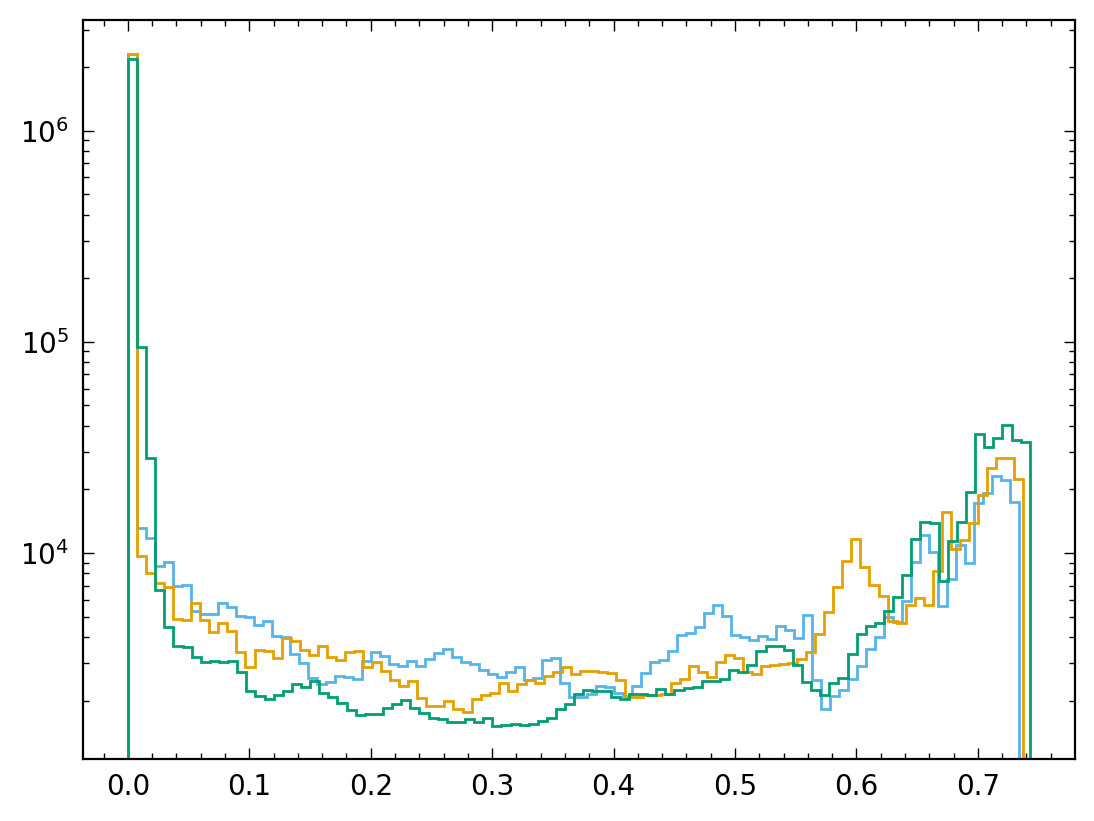

In [4]:
# Inspect distribution of observables
sel = 'peff_clearance'
for a in np.unique(clustered_mean_df.loc[(clustered_mean_df.b_I == b_C)][key_var].values):
    data = clustered_mean_df.loc[clustered_mean_df[key_var] == a]
    plt.hist(data[sel], bins = np.linspace(np.amin(data[sel]), np.amax(data[sel]), 100), histtype = 'step', log = True);

,antigenicity_over_harm,stim_pI,stim_pHI,stim_pHE
0,0.532046,0.000100,0.007459,3.502030
1,0.544286,0.000940,0.061633,3.494131
2,0.556817,0.006924,0.359325,3.489623
3,0.562162,0.000164,0.007459,3.490668
4,0.569737,0.020705,0.815841,3.488733
...,...,...,...,...
223,3.120998,6.308990,2.026681,3.469753
224,3.172940,0.042772,0.872051,3.691884
225,3.349148,6.526384,1.793585,3.516603
226,5.611731,0.362556,0.872051,3.724777


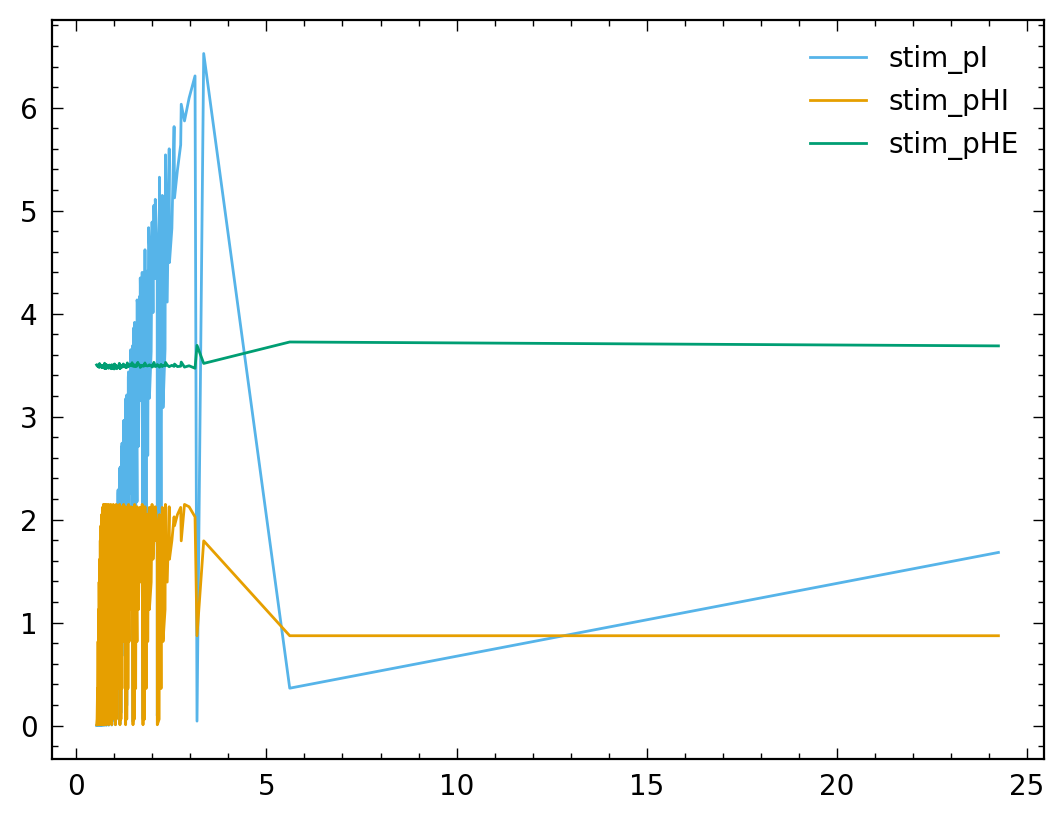

In [5]:
#norm_stim = clustered_mean_df.loc[(np.sum(np.abs(clustered_mean_df[reg_stim]), axis = 1) == 0)].groupby(key_var, as_index = False).mean()[[key_var, 'stim_pI', 'stim_pHI', 'stim_pHE']]
norm_stim = clustered_mean_df.groupby(key_var, as_index = False).max()[[key_var, 'stim_pI', 'stim_pHI', 'stim_pHE']]
with pd.option_context('display.max_columns', None):
    display(norm_stim)
    
plt.plot(norm_stim[key_var], norm_stim[['stim_pI', 'stim_pHI', 'stim_pHE']], label = ['stim_pI', 'stim_pHI', 'stim_pHE'])
plt.legend()

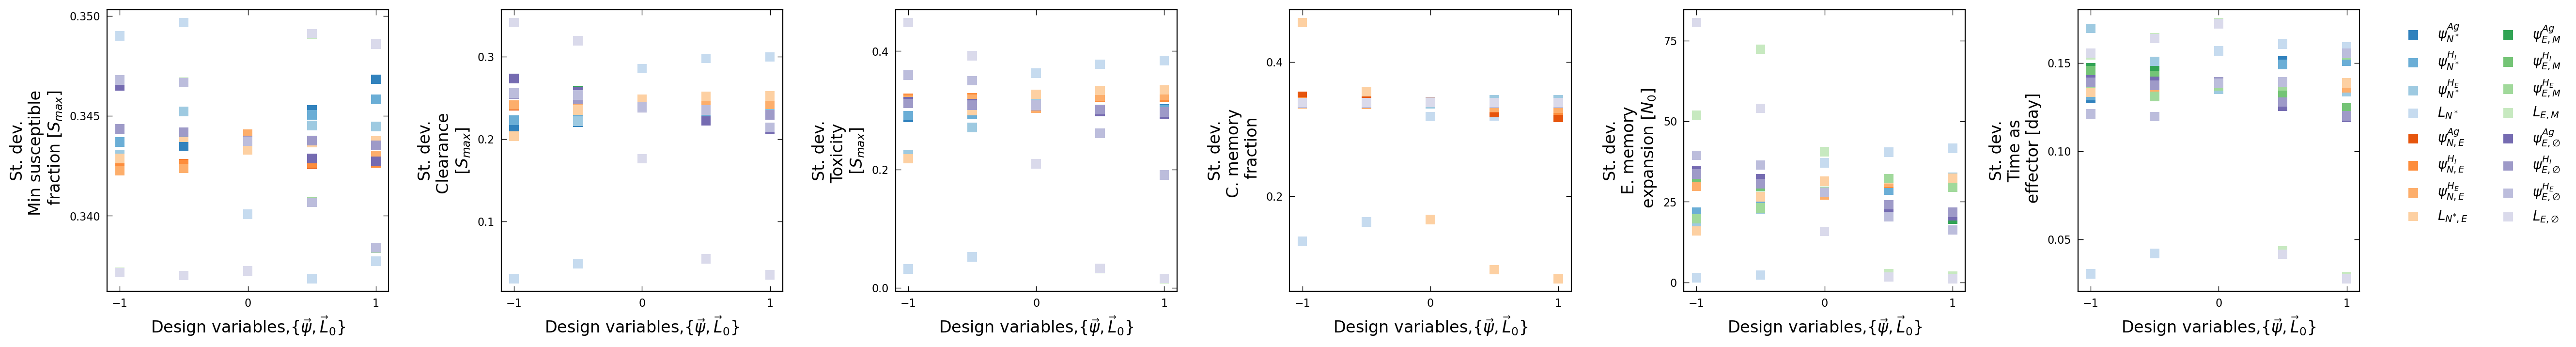

In [6]:
# Explore noise in the data
fig, axs = plt.subplots(1, len(perf_vars), 
                              figsize=(len(perf_vars)**2 - len(perf_vars), 4), sharex=True, sharey=False)


data_mean = clustered_mean_df.groupby(reg + vir_vars, as_index = False).std()
        
for i, var in enumerate(perf_vars):
    im = axs[i].scatter(data_mean[reg_choice[j]]/np.amax(data_mean[reg_choice[j]]), 
                        (10**data_mean[var] - 1) if i == 4 or i == 5 else data_mean[var], 
                      marker = 's', s = 50, color = cmap_colors[module_index*len(reg_choice) + j], 
                        edgecolors = 'None',label = reg_label[module_index*len(reg_choice) + j ])

    if module_index + j == 0: 
        axs[i].minorticks_off()
        axs[i].yaxis.set_tick_params(labelbottom=True)
        axs[i].xaxis.set_tick_params(labelbottom=True)
        axs[i].tick_params(axis='both', which='major', labelsize=8)
        axs[i].set_box_aspect(1)
        axs[i].locator_params(axis='y', nbins=4)
        axs[i].locator_params(axis='x', nbins=4)
        axs[i].set_ylabel("St. dev.\n"+perf_labels[i], fontsize = 12)
        axs[i].set_xlabel(r'Design variables,$\{\vec\psi, \vec L_0 \}$', fontsize = 12)

axs[-1].legend(bbox_to_anchor=(1.1, 1), fontsize=10, framealpha=0, ncol = 2)
fig.subplots_adjust(wspace=.4, hspace=.35)
#plt.savefig('_figs/'+comment+'-'+'mean_regulation_trends_by_performance'+'.png', dpi=150, bbox_inches="tight")

### Fit model to average data
The nonlinear sigmoid model does a good job on the data averaged over infections and marginalized over modules. This is the minimum we require.

fevals: 15
fevals: 31
fevals: 8
fevals: 12
fevals: 66
fevals: 124
fevals: 52
fevals: 15
fevals: 11
fevals: 48
fevals: 7
fevals: 9
fevals: 11
fevals: 48
fevals: 7
fevals: 9


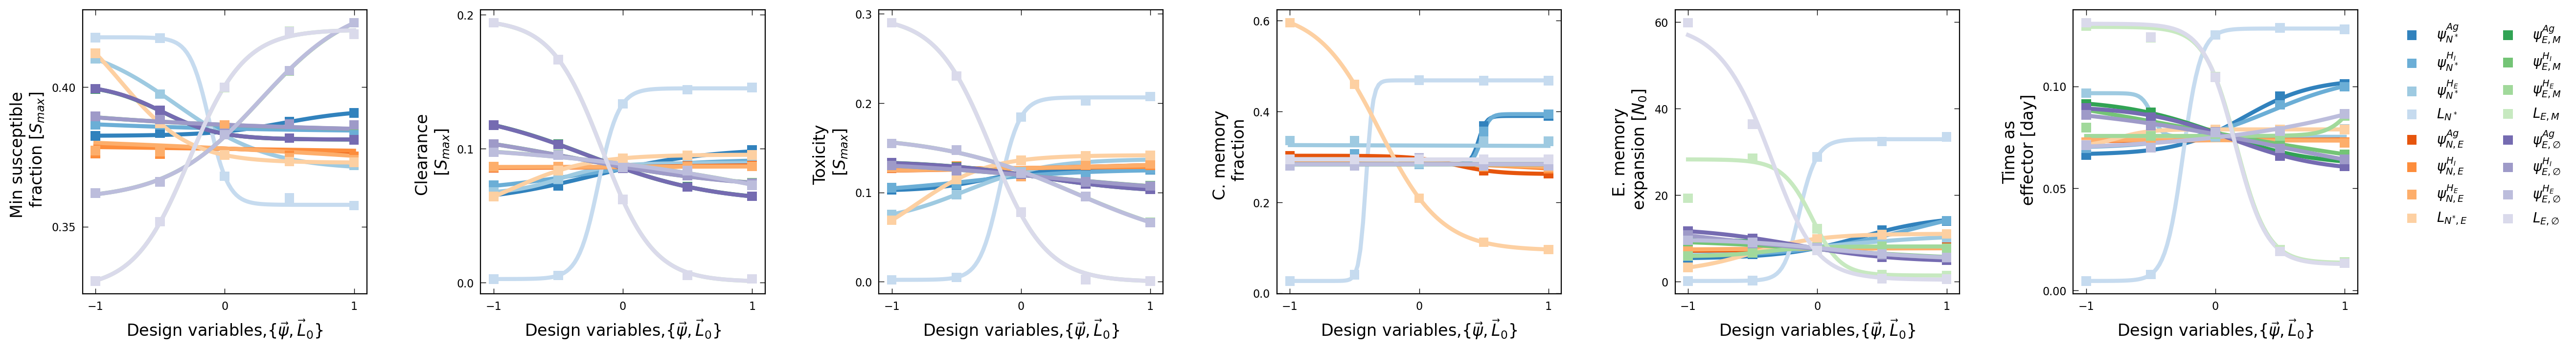

In [25]:
# Fit impact of regulatory parameters on performace: marginalizing over modules
fig, axs = plt.subplots(1, len(perf_vars), 
                              figsize=(len(perf_vars)**2 - len(perf_vars), 4), sharex=True, sharey=False)

for module_index in np.arange(0, len(modules)):
    reg_choice_label = modules[module_index]
    reg_choice = module_reg[reg_choice_label]
    zero_regs = np.concatenate([(module_reg[modules[u]] if u != module_index else []) for u in np.arange(0, len(modules))]).tolist()
    
    x_varname= key_var

    for j, p in enumerate(signal_classes):
        data_mean = clustered_mean_df.groupby(reg_choice[j], as_index = False).mean()
        
        for i, var in enumerate(perf_vars):
            im = axs[i].scatter(data_mean[reg_choice[j]]/np.amax(data_mean[reg_choice[j]]), 
                                (10**data_mean[var] - 1) if i == 4 or i == 5 else data_mean[var], 
                              marker = 's', s = 50, color = cmap_colors[module_index*len(reg_choice) + j], 
                                edgecolors = 'None',label = reg_label[module_index*len(reg_choice) + j ])

            y_max = np.max(data_mean[var].values)
            y_min = np.min(data_mean[var].values)
            y_std = np.std(data_mean[var].values)

            popt, pcov, infodict, _, _ = curve_fit(sigmoid_1d, data_mean[reg_choice[j]].values, data_mean[var].values, 
                                   p0 =(y_max, y_min, 0.0, 0.0),
                                   method = 'trf', 
                                   bounds = ([y_max - tol*y_std, np.minimum(2*y_min, 0), -4*L0_max, -4*L0_max], 
                                             [2*y_max if y_max > 0 else y_std*tol, np.maximum(y_min, 0) + y_std*tol, 4*L0_max, 4*L0_max]),
                                   maxfev=10000,
                                   full_output = True)

            x = np.linspace(-np.max(data_mean[reg_choice[j]]), np.max(data_mean[reg_choice[j]]), 100)
            axs[i].plot(x/np.amax(x), (10**sigmoid_1d(x, *popt) - 1) if i == 4 or i == 5 else sigmoid_1d(x, *popt), 
                        linestyle='-',
                        linewidth = 3.0,
                        color = cmap_colors[module_index*len(reg_choice) + j], 
                        zorder = 0)

            if i == 0:
                print("fevals:", infodict['nfev'])

            if module_index + j == 0: 
                axs[i].minorticks_off()
                axs[i].yaxis.set_tick_params(labelbottom=True)
                axs[i].xaxis.set_tick_params(labelbottom=True)
                axs[i].tick_params(axis='both', which='major', labelsize=8)
                axs[i].set_box_aspect(1)
                axs[i].locator_params(axis='y', nbins=4)
                axs[i].locator_params(axis='x', nbins=4)
                axs[i].set_ylabel(perf_labels[i], fontsize = 12)
                axs[i].set_xlabel(r'Design variables,$\{\vec\psi, \vec L_0 \}$', fontsize = 12)

axs[-1].legend(bbox_to_anchor=(1.1, 1), fontsize=10, framealpha=0, ncol = 2)
fig.subplots_adjust(wspace=.4, hspace=.35)
plt.savefig('_figs/'+comment+'-'+'mean_regulation_trends_by_performance'+'.png', dpi=150, bbox_inches="tight")

In [26]:
del clustered_mean_df

### Fit model to individual infection scenarios and with all regulatory modules as variables

In [27]:
# Regress Performance measures on regulation parameters
num_cpu = 145
variables = reg
tol = 1e-2

def model(input, fit = "non-linear"):

    out = []
    infection = input[vir_vars].values[0]
    runtimes = str(np.round(infection, 3))+': '
    
    for i, perf in enumerate(perf_vars):
        # run regression
        start = time.time() # timestamp start
        
        if fit == "linear":
            input.loc[:,'dep_var'] = np.log(1 + input[perf].values) if 'Memory' in perf_labels[perf_vars.index(perf)] or 'magnitude' in perf_labels[perf_vars.index(perf)] else input[perf].values
            lr = smf.ols('dep_var ~ ' + ' + '.join(variables), data=input).fit()
    
            # save values
            out.append( (lr.params.values[0: 1 + len(variables)]).tolist() + np.sqrt(np.diag(lr.cov_params())).tolist() + infection.tolist() + [np.mean(input[perf].values), i] )
        else:
            y_max = np.max(input[perf].values)
            y_min = np.min(input[perf].values)
            y_std = np.std(input[perf].values)
            popt, pcov = curve_fit(sigmoid, input[variables].values, input[perf].values, 
                           p0 =[y_max, y_min] + len(variables)*[0.0] + num_modules*[0.0],
                           method = 'trf', 
                           bounds = ([y_max - y_std*tol, np.minimum(0.0, y_min)] + len(variables)*[-15*L0_max] + num_modules*[-15*L0_max], 
                                     [1.0 if perf == "frac_cM" else (y_max + y_std*tol), y_min + y_std*tol] + len(variables)*[15*L0_max] + num_modules*[15*L0_max]), 
                                   maxfev=100000,
                                   full_output = False)
            
            residuals = input[perf].values - sigmoid(input[variables].values, *popt)
            rmse = np.sqrt(np.mean(residuals**2))
            out.append(popt.tolist() + np.sqrt(np.diag(pcov)).tolist() + infection.tolist() + [np.mean(input[perf].values), 
                                                                                               np.max(input[perf].values), 
                                                                                               np.min(input[perf].values), 
                                                                                               np.median(input[perf].values), 
                                                                                               i, rmse, y_std, 
                                                                                               np.amax(input['scaled_min_pS'].values),
                                                                                               input['harm_pI_noprotection'].values[0],
                                                                                               np.amax(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pI'].values), 
                                                                                               np.amax(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pHI'].values),
                                                                                               np.amax(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pHE'].values)])

            # if i == 0:
            #     print("fevals:", infodict['nfev'])
        end = time.time() # timestamp start
        runtimes += (perf+ ' = ' + str((end - start)/3600)+' hrs, ')
        
    #print(runtimes)
    out_data = pd.DataFrame(np.vstack(out), 
                            columns = ['y_max', 'y_min'] \
                            + variables + [('intercept_' + j) for j in modules] \
                            + ['sigma_y_max', 'sigma_y_min'] + ['sigma_'+r  for r in variables] \
                            + [('sigma_intercept_' + j) for j in modules] \
                            + vir_vars \
                            + ['mean_perf', 'max_perf', 'min_perf', 'median_perf', 'perf_index', 'rmse', 'y_std', 'max_scaled_min_pS', 'harm_pI_noprotection', 'stim_pI', 'stim_pHI', 'stim_pHE'])
    out_data['antigenicity_over_harm'] = antigenicity_over_harm(out_data)
    out_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/fits/'+comment+runs+'fit_'+str(np.round(infection, 3))+'.pkl')
    
    return np.vstack(out)

# Compile datasets
impact_data = pd.DataFrame(np.vstack(Parallel(n_jobs = num_cpu, batch_size = max(int(n_virs/num_cpu),1))(delayed(model)(input = data.groupby(vir_vars + variables, as_index=False).mean(), fit = "nonlinear") 
                                                                                                            for data in infection_scenarios)), 
                            columns = ['y_max', 'y_min'] \
                            + variables + [('intercept_' + j) for j in modules] \
                            + ['sigma_y_max', 'sigma_y_min'] + ['sigma_'+r  for r in variables] \
                            + [('sigma_intercept_' + j) for j in modules] \
                            + vir_vars \
                            + ['mean_perf', 'max_perf', 'min_perf', 'median_perf', 'perf_index', 'rmse', 'y_std', 'max_scaled_min_pS', 'harm_pI_noprotection', 'stim_pI', 'stim_pHI', 'stim_pHE'])
impact_data['antigenicity_over_harm'] = antigenicity_over_harm(impact_data)

impact_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+runs+'impact_data'+'.pkl')

In [28]:
# # IF the above fails: Compile datasets
# num_cpu = 150
# file_list = [f for f in os.listdir(d) if comment in f]
# num_files = len(file_list)

# def import_fits(f,d):
    
#     file_path = os.path.join(d, f)
#     with open(file_path, 'rb') as filename:  
#         out = pickle.load(filename)

#     return out

# impact_data = pd.concat(Parallel(n_jobs = num_cpu, batch_size = max(int(n_virs/num_cpu),1))(delayed(import_fits)(f = file_name, d = d) 
#                                                                                                             for file_name in file_list))
# impact_data['antigenicity_over_harm'] = antigenicity_over_harm(impact_data)

# impact_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+runs+'impact_data'+'.pkl')

In [29]:
# View result
perf_choice = 1 # chose observable
impact_data = pd.read_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+runs+'impact_data'+'.pkl')
with pd.option_context('display.max_columns', None,'display.max_rows', None):
    display(impact_data.loc[(impact_data.perf_index == perf_choice)])

,y_max,y_min,psi_myc_I,psi_myc_HI,psi_myc_HE,L0_Na,psi_NE_I,psi_NE_HI,psi_NE_HE,L0_NE,psi_EM_I,psi_EM_HI,psi_EM_HE,L0_EM,psi_Edie_I,psi_Edie_HI,psi_Edie_HE,L0_Edie,intercept_Na,intercept_NE,intercept_EM,intercept_EE,sigma_y_max,sigma_y_min,sigma_psi_myc_I,sigma_psi_myc_HI,sigma_psi_myc_HE,sigma_L0_Na,sigma_psi_NE_I,sigma_psi_NE_HI,sigma_psi_NE_HE,sigma_L0_NE,sigma_psi_EM_I,sigma_psi_EM_HI,sigma_psi_EM_HE,sigma_L0_EM,sigma_psi_Edie_I,sigma_psi_Edie_HI,sigma_psi_Edie_HE,sigma_L0_Edie,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EM,sigma_intercept_EE,d_I,K_I,b_I,K_H,N_0,S_0,I_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,max_scaled_min_pS,harm_pI_noprotection,stim_pI,stim_pHI,stim_pHE,antigenicity_over_harm
1,1.140163,3.336671e-03,3.980979,0.041439,0.103718,3.968486,0.314412,-0.000282,0.001920,1.093395,-7.002330,-0.305126,-0.404100,-3.773289,-7.034355,-0.311483,-0.397395,-3.790394,3.693435,5.372493,-1.914524,-1.918982,0.000888,2.030712e-04,3.368392e-02,5.210227e-03,5.250156e-03,3.394016e-02,0.005589,0.005340,0.005340,0.015730,0.044719,0.006787,0.007161,2.562854e-02,0.045026,0.006835,0.007161,2.583631e-02,3.432524e-02,6.374455e-02,0.007727,0.007755,0.150000,1.000000e+04,1.500000e-07,100000.0,100.0,10000000.0,1000.0,0.127022,1.136826,0.000000e+00,0.000096,1.0,0.100437,0.333667,0.968333,1.138419,6.526300,1.793448,3.342250,3.349148
7,1.139883,3.314231e-03,3.649844,0.069988,0.161777,3.929105,0.228787,0.013992,0.001587,1.260439,-4.887472,-0.273037,-0.347886,-2.925856,-4.876847,-0.271271,-0.343038,-2.919981,3.420770,6.140460,-1.732158,-1.732759,0.001040,2.116641e-04,3.015482e-02,5.621785e-03,5.729991e-03,3.147341e-02,0.006060,0.005928,0.005927,0.026080,0.029803,0.005256,0.005399,1.987175e-02,0.029688,0.005246,0.005381,1.980555e-02,2.913917e-02,1.053800e-01,0.006958,0.006959,0.150000,1.637894e+04,1.500000e-07,100000.0,100.0,10000000.0,1000.0,0.125823,1.136569,0.000000e+00,0.000087,1.0,0.104476,0.331423,0.947153,1.138419,6.033823,1.793448,3.338617,2.758122
13,1.139449,3.283589e-03,3.404717,0.091335,0.344368,4.265464,0.146723,0.009154,0.001386,1.042163,-3.964154,-0.192552,-0.367870,-3.883955,-3.962521,-0.184911,-0.365558,-3.882581,3.172165,5.112144,-1.884341,-1.886253,0.000921,1.976162e-04,2.856419e-02,6.238042e-03,6.860582e-03,3.356912e-02,0.005186,0.005128,0.005128,0.014827,0.024483,0.005131,0.005530,2.182129e-02,0.024481,0.005120,0.005525,2.180611e-02,2.553764e-02,6.002752e-02,0.007406,0.007416,0.150000,2.682696e+04,1.500000e-07,100000.0,100.0,10000000.0,1000.0,0.124059,1.136165,0.000000e+00,0.000077,1.0,0.098333,0.328359,0.913752,1.138419,5.541939,1.793448,3.342902,2.344404
19,1.139011,3.250552e-03,3.235695,0.112299,1.051799,5.686330,0.101154,-0.005440,0.000793,1.103776,-3.553830,-0.203340,-0.376205,-3.760121,-3.539174,-0.202206,-0.378848,-3.737758,3.091556,5.342886,-1.947498,-1.941439,0.000865,1.843882e-04,2.871198e-02,6.547020e-03,1.057496e-02,4.620493e-02,0.004848,0.004821,0.004821,0.015569,0.017688,0.004669,0.005098,1.821599e-02,0.017619,0.004652,0.005089,1.808358e-02,2.349858e-02,6.296077e-02,0.007295,0.007259,0.150000,4.393971e+04,1.500000e-07,100000.0,100.0,10000000.0,1000.0,0.121831,1.135761,0.000000e+00,0.000066,1.0,0.092221,0.325055,0.896071,1.138419,5.051025,1.793448,3.357009,2.038612
25,1.138339,3.216668e-03,3.358266,0.161273,1.788714,9.671168,0.076567,0.004477,-0.002613,1.210627,-2.535479,-0.284963,-0.531587,-3.108648,-2.529081,-0.282162,-0.533629,-3.093085,3.736442,5.819489,-1.860943,-1.866122,0.000859,1.757028e-04,3.476490e-02,8.506970e-03,2.138842e-02,9.985762e-02,0.004750,0.004735,0.004735,0.019190,0.011897,0.004108,0.004631,1.410395e-02,0.011823,0.004091,0.004622,1.395883e-02,3.973216e-02,7.751940e-02,0.006371,0.006387,0.150000,7.196857e+04,1.500000e-07,100000.0,100.0,10000000.0,1000.0,0.119450,1.135122,0.000000e+00,0.000057,1.0,0.087873,0.321667,0.873341,1.138419,4.561689,1.793448,3.330776,1.803387
31,1.137359,3.178423e-03,3.036751,0.228878,3.025651,11.651444,0.059158,0.001766,0.002569,1.16

#### Check the model goodness of the fit
The model does a pretty good job as the $R^2$ values for clearance, toxicity and memory are above 0.80.

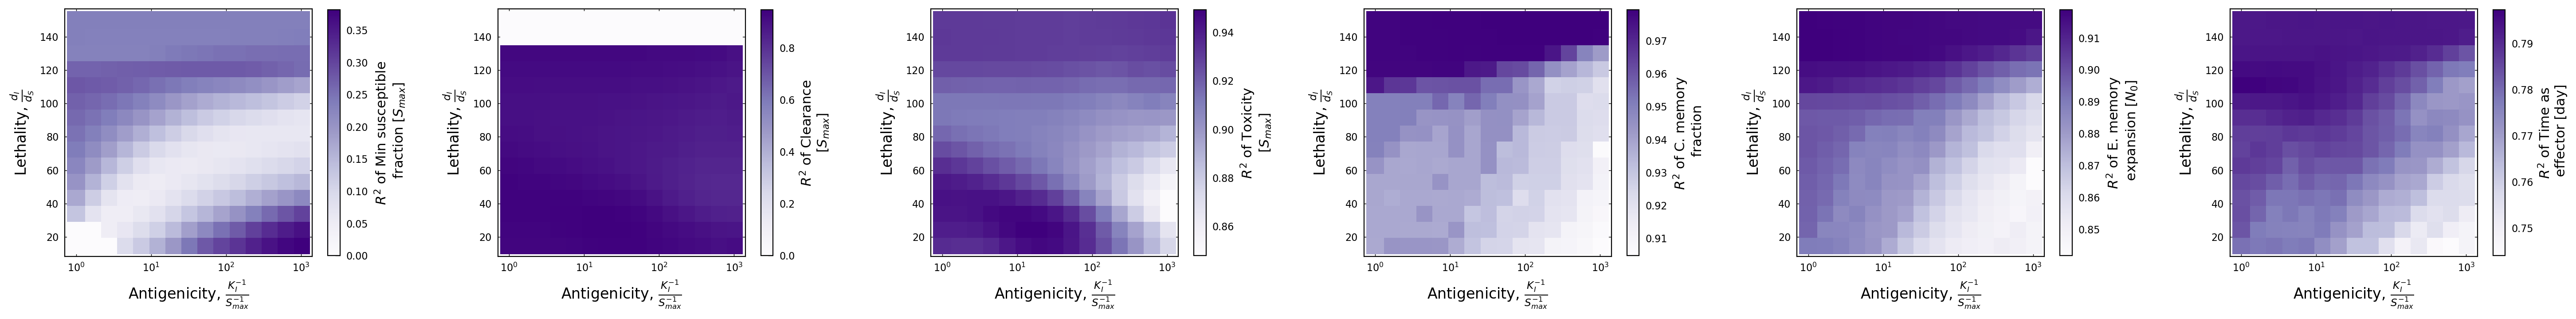

In [30]:
# Examine goodness of fit through R-squared
plots = [vir_vars[1], vir_vars[0]]
plot_labels = ["Antigenicity, "+r"$\frac{K_{I}^{-1}}{S_{max}^{-1}}$", "Lethality, "+r"$\frac{d_{I}}{d_{S}}$"]
size = 3200/np.sqrt(len(infection_scenarios))

fig, axs = plt.subplots(1, len(perf_vars), 
                          figsize=(len(perf_vars)**2, 2*len(perf_vars)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, perf in enumerate(perf_vars):
    data = impact_data[(impact_data.perf_index == i)*(impact_data.I_0 <= I_min)]
    model_r_sq = (1 - data.rmse**2/data.y_std**2)*(data.y_std > tol)
    z_label = r"$R^2$ of "+perf_labels[i]
    
    im = axs[i].scatter(data['S_0']/data[x_varname] if x_varname == 'K_I' else data[x_varname]/d_S,
                                 data['S_0']/data[y_varname] if y_varname == 'K_I' else data[y_varname]/d_S,
                      marker ='s', s = size, c = model_r_sq, cmap='Purples', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    if x_varname == 'K_I':
        axs[i].semilogx()
    if y_varname == 'K_I':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)

    cb = fig.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.30, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig.subplots_adjust(wspace=0.40, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

plt.savefig('_figs/'+comment+'-fits-r-squared'+'.png', dpi=150, bbox_inches="tight")

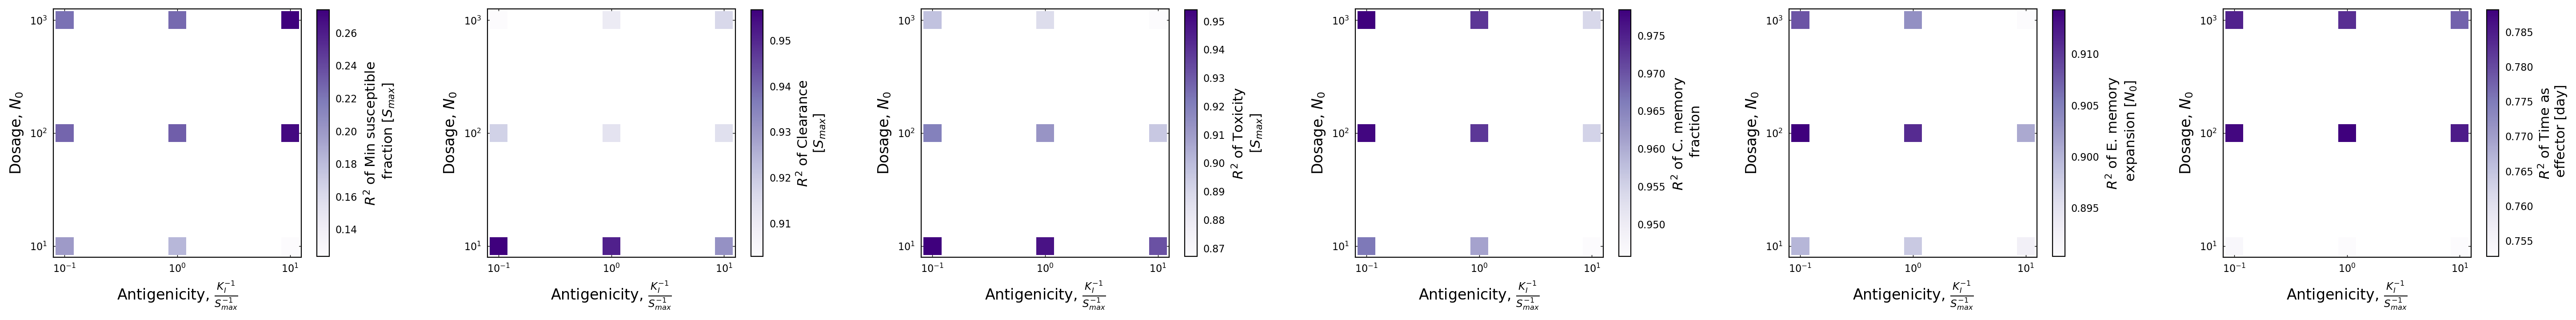

In [31]:
# Examine goodness of fit through R-squared
size = 3200/np.sqrt(len(infection_scenarios))

fig, axs = plt.subplots(1, len(perf_vars), 
                          figsize=(len(perf_vars)**2, 2*len(perf_vars)), sharex='row', sharey='col')

x_varname, y_varname = vir_vars[1], vir_vars[4]
for i, perf in enumerate(perf_vars):
    data = impact_data[(impact_data.perf_index == i)*(impact_data.I_0 > I_min)]
    model_r_sq = (1 - data.rmse**2/data.y_std**2) #*(data.y_std > tol)
    z_label = r"$R^2$ of "+perf_labels[i]
    
    im = axs[i].scatter(data['S_0']/data[x_varname], data[y_varname],
                      marker ='s', s = size, c = model_r_sq, cmap='Purples', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    axs[i].semilogx()
    axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)

    cb = fig.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.30, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig.subplots_adjust(wspace=0.40, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel("Antigenicity, "+r"$\frac{K_{I}^{-1}}{S_{max}^{-1}}$", fontsize = 12)
    ax.set_ylabel("Dosage, "+r"$N_0$", fontsize = 12)

plt.savefig('_figs/'+comment+'-fits-r-squared-cancers'+'.png', dpi=150, bbox_inches="tight")

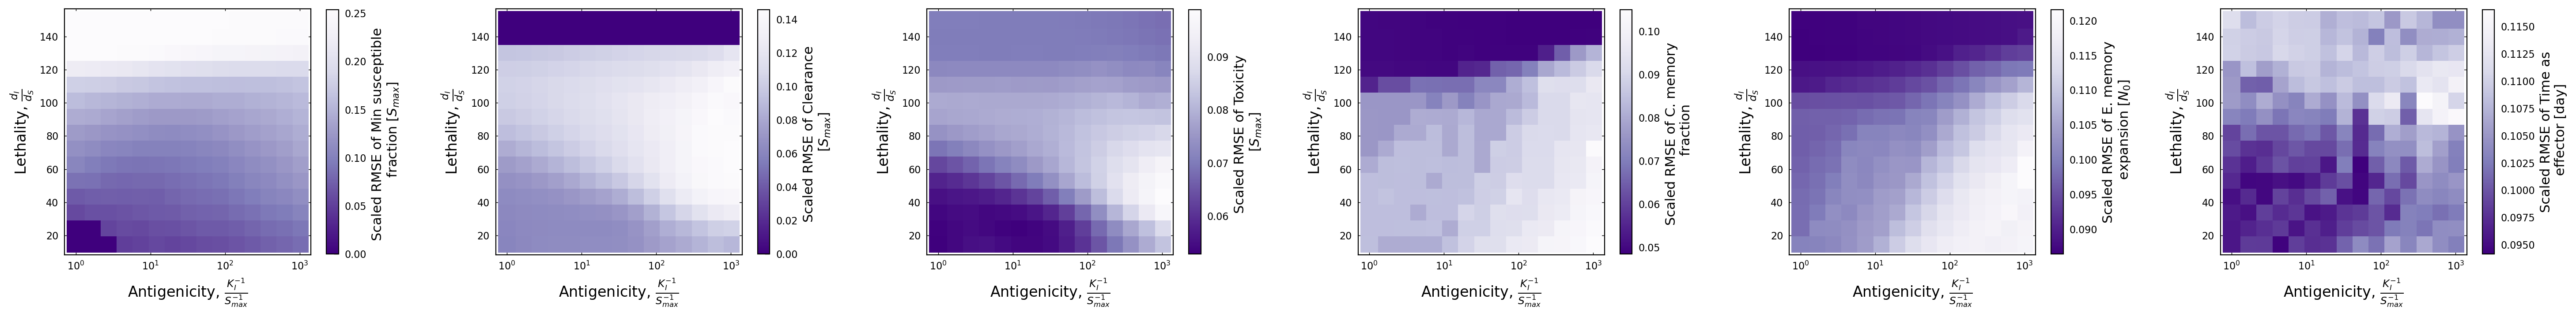

In [32]:
# Examine goodness of fit through scaled-RMSE
fig, axs = plt.subplots(1, len(perf_vars), 
                          figsize=(len(perf_vars)**2, 2*len(perf_vars)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, perf in enumerate(perf_vars):
    data = impact_data[(impact_data.perf_index == i)*(impact_data.I_0 <= I_min)]
    model_rmse_over_max = (data.rmse/data.y_max)*(data.y_std > tol)
    z_label = "Scaled RMSE of "+perf_labels[i]
    
    im = axs[i].scatter(data['S_0']/data[x_varname] if x_varname == 'K_I' else data[x_varname]/d_S,
                                 data['S_0']/data[y_varname] if y_varname == 'K_I' else data[y_varname]/d_S,
                      marker ='s', s = size, 
                        c = model_rmse_over_max, cmap='Purples_r', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    if x_varname == 'K_I':
        axs[i].semilogx()
    if y_varname == 'K_I':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)

    cb = fig.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.30, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig.subplots_adjust(wspace=0.40, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

plt.savefig('_figs/'+comment+'-fits-scaled-rmse'+'.png', dpi=150, bbox_inches="tight")

Effector memory expansion appears challenging to fit based on the $R^2$ values. Looks much better when we look at scaled RMSE. Rationalize by observing tha effector memory expansion has non-monotonic dependence on some variables which can lead to a low variance estimate, and make the $R^2$ values look bad.

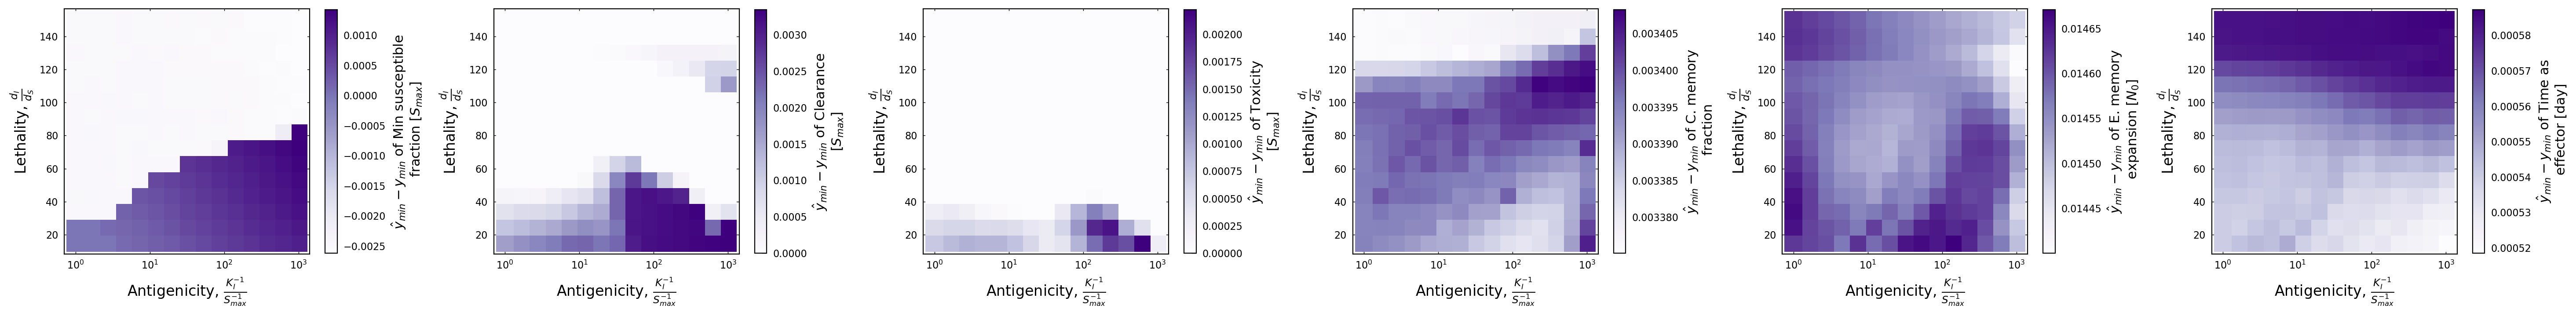

In [33]:
# Examine difference between observed and predicted minima
fig, axs = plt.subplots(1, len(perf_vars), 
                          figsize=(len(perf_vars)**2, 2*len(perf_vars)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, perf in enumerate(perf_vars):
    data = impact_data[(impact_data.perf_index == i)*(impact_data.I_0 <= I_min)]
    z_label = r"$\hat{y}_{min} - y_{min}$ of "+perf_labels[i]
    
    im = axs[i].scatter(data['S_0']/data[x_varname] if x_varname == 'K_I' else data[x_varname]/d_S,
                                 data['S_0']/data[y_varname] if y_varname == 'K_I' else data[y_varname]/d_S,
                      marker ='s', s = size, c = (data.y_min - data.min_perf)*(data.y_std > tol), cmap='Purples', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    if x_varname == 'K_I':
        axs[i].semilogx()
    if y_varname == 'K_I':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)

    cb = fig.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.30, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig.subplots_adjust(wspace=0.40, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

plt.savefig('_figs/'+comment+'-fits-y_min'+'.png', dpi=150, bbox_inches="tight")

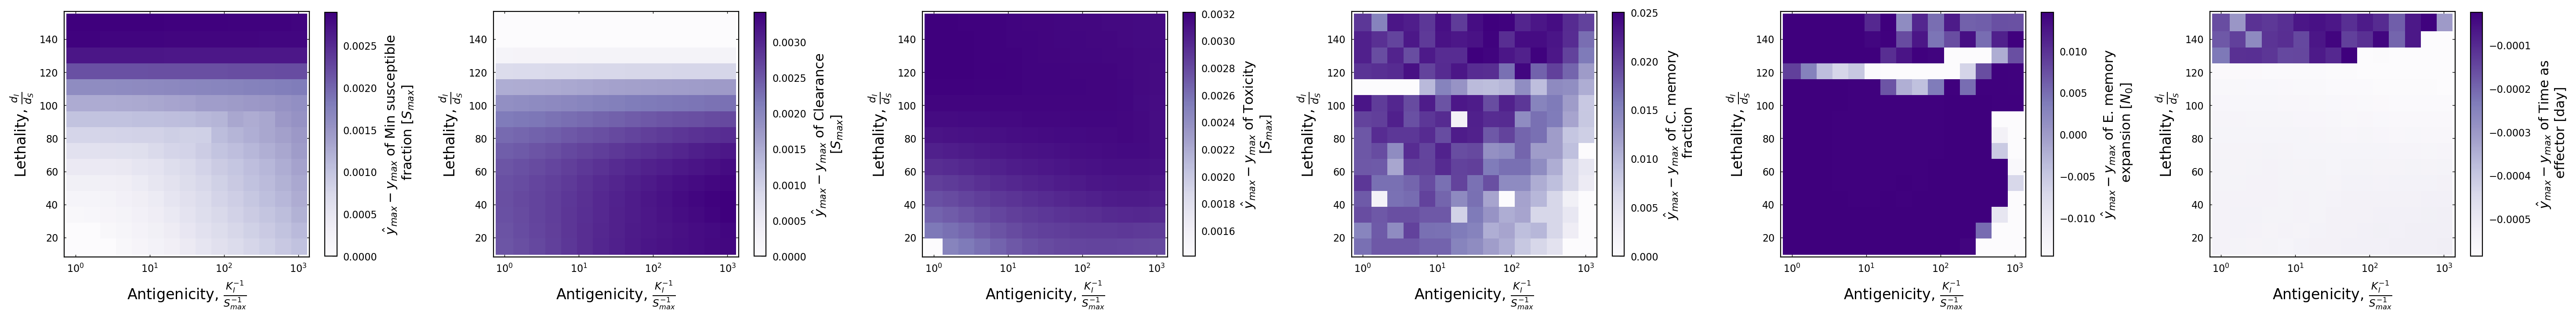

In [34]:
# Examine difference between observed and predicted maxima
plots = [vir_vars[1], vir_vars[0]]

fig, axs = plt.subplots(1, len(perf_vars), 
                          figsize=(len(perf_vars)**2, 2*len(perf_vars)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, perf in enumerate(perf_vars):
    data = impact_data[(impact_data.perf_index == i)*(impact_data.I_0 <= I_min)]
    z_label = r"$\hat{y}_{max} - y_{max}$ of "+perf_labels[i]
    
    im = axs[i].scatter(data['S_0']/data[x_varname] if x_varname == 'K_I' else data[x_varname]/d_S,
                                 data['S_0']/data[y_varname] if y_varname == 'K_I' else data[y_varname]/d_S,
                      marker ='s', s = size, c = (data.y_max - data.max_perf)*(data.y_std > tol), cmap='Purples', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    if x_varname == 'K_I':
        axs[i].semilogx()
    if y_varname == 'K_I':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)

    cb = fig.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.30, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig.subplots_adjust(wspace=0.40, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

plt.savefig('_figs/'+comment+'-fits-y_max'+'.png', dpi=150, bbox_inches="tight")

The distribution of the values of the bias parameters gives us a sense of how well our simulations can explain variation due to that module. In this case the Naive to Memory module has a computed bias for clearance/toxicity that is at the maximum allowable. However the value is less extreme for memory formation. This suggests a strong bias towards high clearance/toxicity in this module.

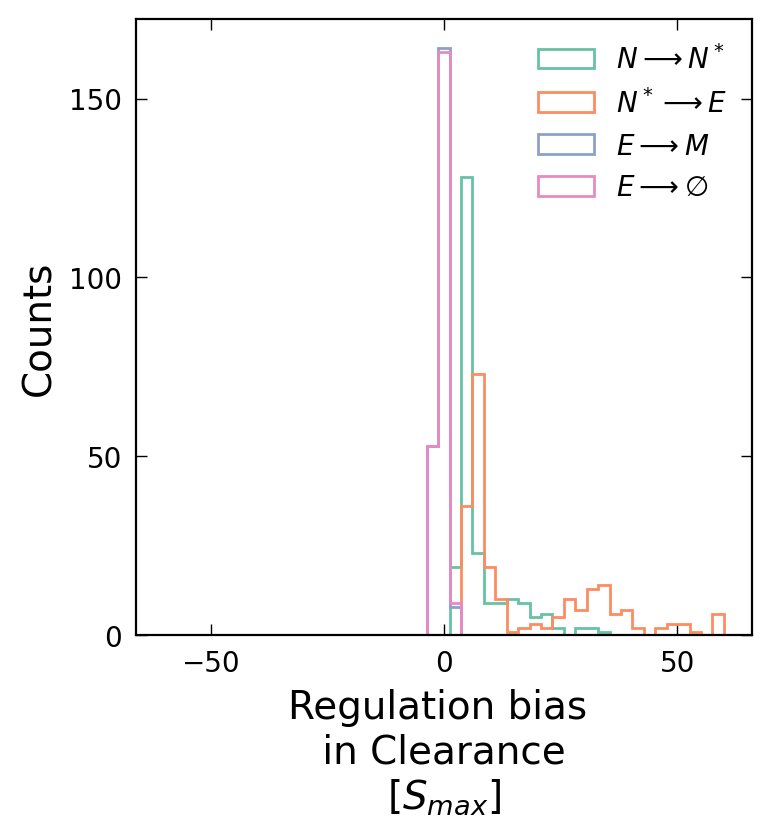

In [35]:
fig, axs = plt.subplots(figsize=(4,4), sharex=False, sharey=False)

cmap_colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
for i, r in enumerate(modules):
    data = impact_data[(impact_data.perf_index == perf_choice)*(impact_data.I_0 <= I_min)]['intercept_'+r].values
    axs.hist(data, bins = np.linspace(-15*L0_max, 15*L0_max, 50), histtype = 'step', label = module_labels[i], color = cmap_colors[i], stacked = True);

axs.legend(fontsize = 10, ncol = 1)

axs.set_xlabel("Regulation bias \n in "+perf_labels[perf_choice], fontsize = 14)
axs.set_ylabel("Counts", fontsize = 14)
axs.set_box_aspect(1)
axs.minorticks_off()
axs.locator_params(axis='y', nbins=4)
axs.locator_params(axis='x', nbins=4)

#plt.savefig('_figs/'+comment+'-optimal-reg-average_utility'+'.png', dpi=150, bbox_inches="tight")

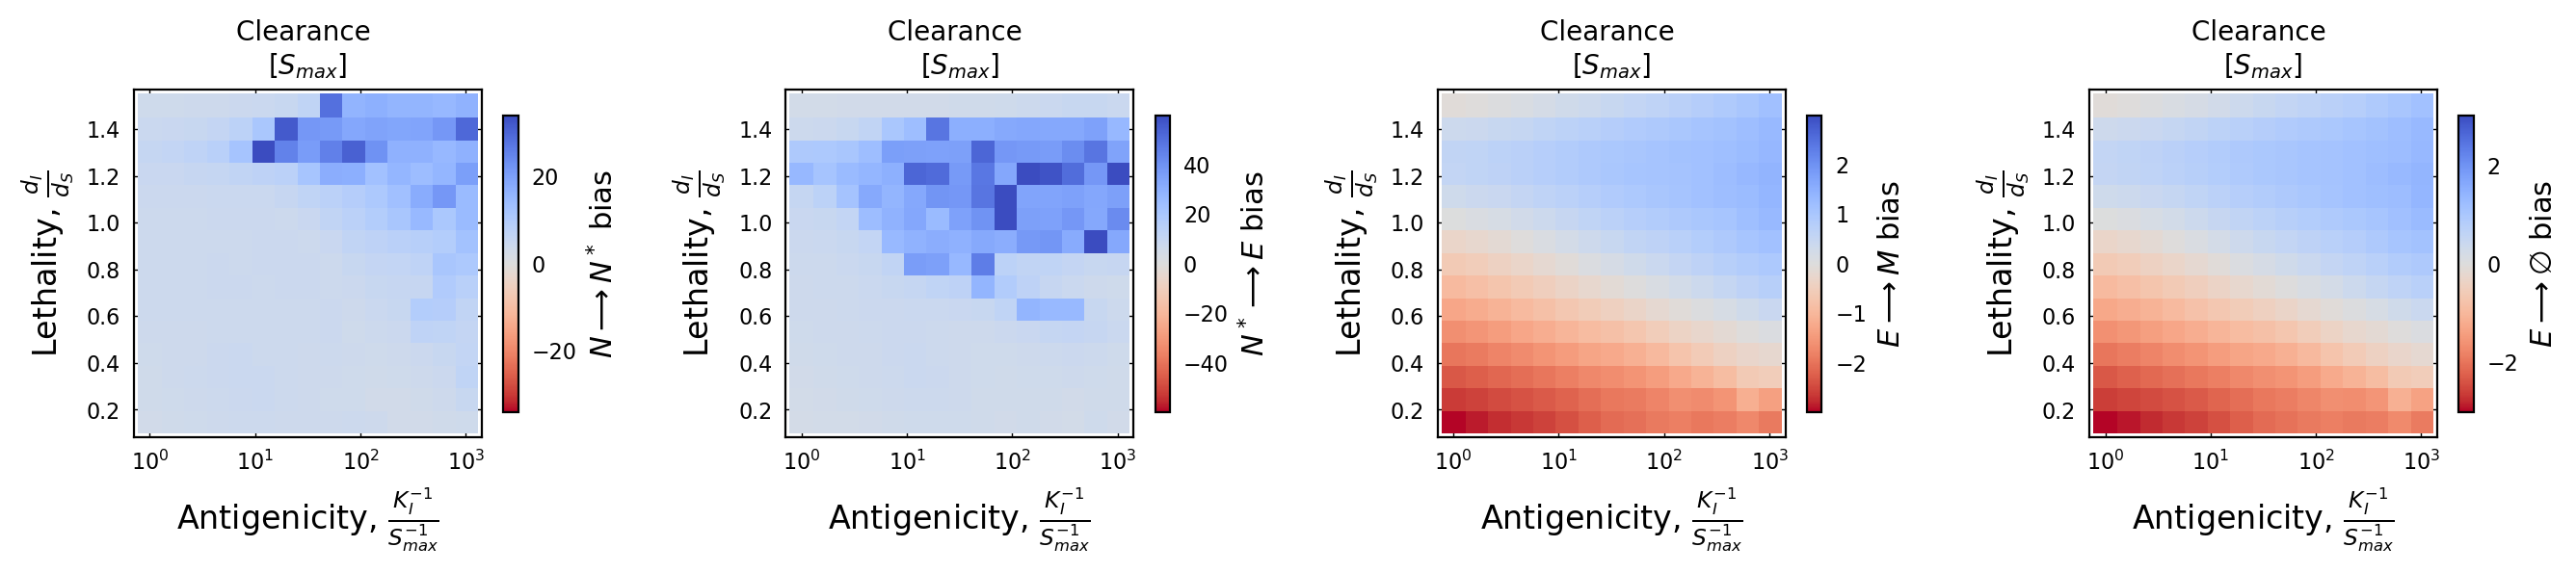

In [36]:
# Visualize optimal regulation
plots = [vir_vars[1], vir_vars[0]]
size = 1250/np.sqrt(len(infection_scenarios))

data = impact_data[(impact_data.perf_index == perf_choice)*(impact_data.I_0 <= I_min)]

fig_c, axs = plt.subplots(1, len(modules), 
                          figsize=(len(modules)**2, 2*len(modules)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, r in enumerate(modules):
    z_varname = 'intercept_'+r
    z_label = module_labels[i]+" bias"
    z = data[z_varname]
    range = np.amax(np.abs(z))
    
    im = axs[i].scatter(S_0/data[x_varname] if x_varname == 'K_I' else data[x_varname],
                                 1/data[y_varname] if y_varname == 'K_I' else data[y_varname],
                      marker ='s', s = size, c = z, cmap='coolwarm_r', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize(vmin = -range, vmax = range))

    if x_varname == 'K_I':
        axs[i].semilogx()
    if y_varname == 'K_I':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)
    axs[i].set_title(perf_labels[perf_choice], fontsize = 10.0)

    cb = fig_c.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.25, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig_c.subplots_adjust(wspace=.5, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

# plt.savefig('_figs/'+comment+'-optimal-reg-average_prot_tox_hmap'+'.png', dpi=150, bbox_inches="tight")

These intercept values are important because they tell you what the value of the observable would be if we ran our processes, without regulation, at half their maximal characteristic rates. A positive value means that the half-max rate leads to above-median performance/cost. It would be useful to convert these to rates.

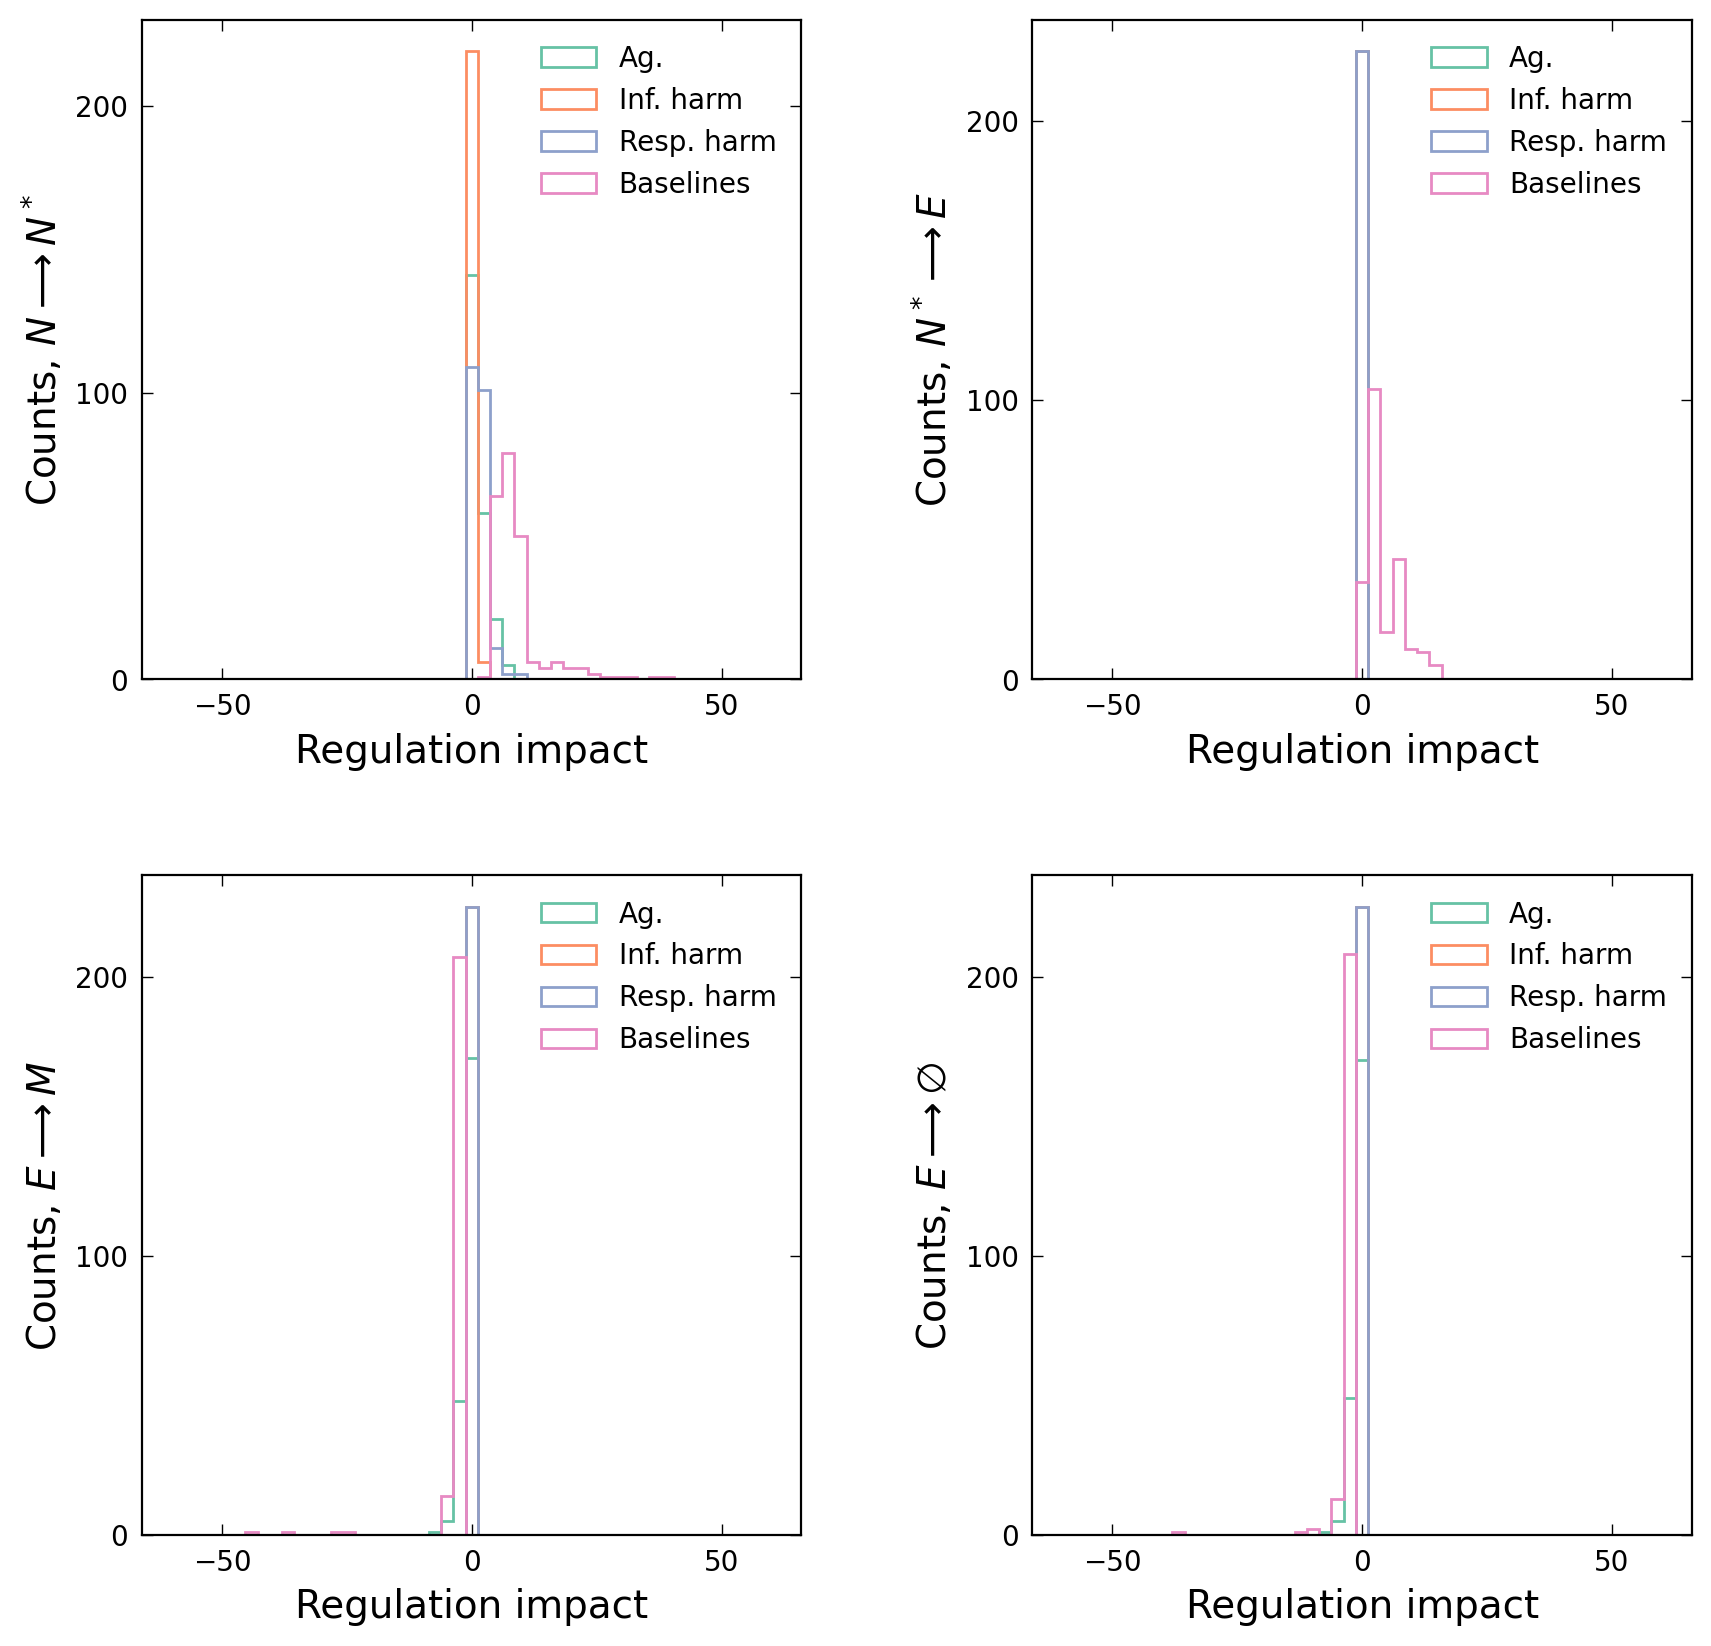

In [37]:
fig, axs = plt.subplots(2,2, figsize=(10,10), sharex=False, sharey=False)

for i, r in enumerate(reg):
    data = impact_data[(impact_data.perf_index == perf_choice)*(impact_data.I_0 <= I_min)][r].values
    module = i // num_modules
    cmap_colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
    
    x, y = module // 2, module % 2
    axs[x,y].hist(data, bins = np.linspace(-15*L0_max, 15*L0_max, 50), histtype = 'step', label = signal_classes[i % num_modules], color = cmap_colors[i % num_modules], stacked = True);

    if (i % num_modules) == num_modules -1:
        axs[x,y].legend(fontsize = 10, ncol = 1)
    
        axs[x,y].set_xlabel("Regulation impact", fontsize = 14)
        axs[x,y].set_ylabel("Counts, "+module_labels[i // num_modules], fontsize = 14)
        axs[x,y].set_box_aspect(1)
        axs[x,y].minorticks_off()
        axs[x,y].locator_params(axis='y', nbins=4)
        axs[x,y].locator_params(axis='x', nbins=4)

fig.subplots_adjust(wspace=.35, hspace=.25)

#plt.savefig('_figs/'+comment+'-optimal-reg-average_utility'+'.png', dpi=150, bbox_inches="tight")

In [38]:
with pd.option_context('display.max_columns', None):
    display(impact_data.loc[(impact_data.perf_index == perf_choice)*(impact_data.b_I == 0.0)])

,y_max,y_min,psi_myc_I,psi_myc_HI,psi_myc_HE,L0_Na,psi_NE_I,psi_NE_HI,psi_NE_HE,L0_NE,psi_EM_I,psi_EM_HI,psi_EM_HE,L0_EM,psi_Edie_I,psi_Edie_HI,psi_Edie_HE,L0_Edie,intercept_Na,intercept_NE,intercept_EM,intercept_EE,sigma_y_max,sigma_y_min,sigma_psi_myc_I,sigma_psi_myc_HI,sigma_psi_myc_HE,sigma_L0_Na,sigma_psi_NE_I,sigma_psi_NE_HI,sigma_psi_NE_HE,sigma_L0_NE,sigma_psi_EM_I,sigma_psi_EM_HI,sigma_psi_EM_HE,sigma_L0_EM,sigma_psi_Edie_I,sigma_psi_Edie_HI,sigma_psi_Edie_HE,sigma_L0_Edie,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EM,sigma_intercept_EE,d_I,K_I,b_I,K_H,N_0,S_0,I_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,max_scaled_min_pS,harm_pI_noprotection,stim_pI,stim_pHI,stim_pHE,antigenicity_over_harm


In [39]:
with pd.option_context('display.max_columns', None):
    display(impact_data.loc[(impact_data.perf_index == perf_choice)*(impact_data.b_I == b_C)])

,y_max,y_min,psi_myc_I,psi_myc_HI,psi_myc_HE,L0_Na,psi_NE_I,psi_NE_HI,psi_NE_HE,L0_NE,psi_EM_I,psi_EM_HI,psi_EM_HE,L0_EM,psi_Edie_I,psi_Edie_HI,psi_Edie_HE,L0_Edie,intercept_Na,intercept_NE,intercept_EM,intercept_EE,sigma_y_max,sigma_y_min,sigma_psi_myc_I,sigma_psi_myc_HI,sigma_psi_myc_HE,sigma_L0_Na,sigma_psi_NE_I,sigma_psi_NE_HI,sigma_psi_NE_HE,sigma_L0_NE,sigma_psi_EM_I,sigma_psi_EM_HI,sigma_psi_EM_HE,sigma_L0_EM,sigma_psi_Edie_I,sigma_psi_Edie_HI,sigma_psi_Edie_HE,sigma_L0_Edie,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EM,sigma_intercept_EE,d_I,K_I,b_I,K_H,N_0,S_0,I_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,max_scaled_min_pS,harm_pI_noprotection,stim_pI,stim_pHI,stim_pHE,antigenicity_over_harm
1351,0.723029,6.997367e-42,4.039852,2.002702,1.105109,5.832918,0.541613,0.273087,0.007535,1.227621,-1.233169,-0.666437,-0.426144,-1.981319,-1.231604,-0.668216,-0.431373,-1.984483,3.571251,4.940468,-0.837837,-0.834015,0.000593,0.000105,0.034281,0.017656,0.010911,0.048832,0.004676,0.004065,0.003814,0.007003,0.005886,0.004039,0.003455,0.008175,0.005900,0.004054,0.003473,0.008220,0.030011,0.027786,0.003390,0.003386,0.01,1000000.0,0.1,100000.0,10.0,10000000.0,500000.0,0.076507,0.721065,0.0,0.000015,1.0,0.051317,0.196411,0.808923,0.823995,1.680823,0.872051,2.409634,24.253500
1357,0.734790,5.670252e-37,3.927310,1.941691,1.080870,5.680445,0.378575,0.199477,0.015743,1.175774,-1.591297,-0.838850,-0.451290,-2.424834,-1.587499,-0.838527,-0.449601,-2.418368,3.540795,6.351978,0.234229,0.232511,0.000586,0.000148,0.036346,0.018740,0.011760,0.051792,0.006781,0.006602,0.006454,0.028104,0.011584,0.006963,0.005046,0.016606,0.011537,0.006949,0.005030,0.016528,0.032393,0.114141,0.003682,0.003681,0.01,1000000.0,0.1,100000.0,100.0,10000000.0,500000.0,0.108806,0.732380,0.0,0.000168,1.0,0.070593,0.240998,0.809440,0.823995,1.680823,0.872051,3.381924,24.253500
1363,0.745028,2.006062e-04,3.653195,1.697534,1.078214,5.407540,0.284487,0.144693,0.000997,4.428373,-1.444255,-0.761997,-0.540694,-2.323761,-1.447452,-0.764057,-0.541022,-2.327777,3.649036,20.423965,0.722675,0.722629,0.000570,0.000162,0.033503,0.016597,0.011624,0.048732,0.013870,0.013763,0.013349,56.488603,0.008847,0.005674,0.004860,0.012858,0.008879,0.005691,0.004868,0.012906,0.033341,225.959102,0.004230,0.004230,0.01,1000000.0,0.1,100000.0,1000.0,10000000.0,500000.0,0.127023,0.742412,0.0,0.001666,1.0,0.075467,0.261555,0.830006,0.823995,1.680823,0.872051,3.662358,24.253500
1369,0.705273,2.518601e-38,0.770557,2.693442,1.354721,6.912206,0.065962,0.251696,0.028934,1.128649,-0.124396,-0.527757,-0.724423,-1.553394,-0.126244,-0.527452,-0.723749,-1.553404,3.487298,3.900411,-1.705688,-1.707382,0.000546,0.000067,0.007969,0.019837,0.011583,0.048963,0.002669,0.002757,0.002663,0.003550,0.002025,0.002267,0.002470,0.002998,0.002025,0.002266,0.002468,0.002998,0.024991,0.013230,0.003900,0.003903,0.01,10000000.0,0.1,100000.0,10.0,10000000.0,500000.0,0.051679,0.703770,0.0,0.000004,1.0,0.033210,0.150253,0.650485,0.823995,0.362556,0.872051,2.457917,5.611731
1375,0.728039,3.542320e-42,0.808116,2.683805,1.628206,6.958262,0.047282,0.178558,0.029533,1.043015,-0.170923,-0.713504,-0.513635,-1.907966,-0.170000,-0.713923,-0.515838,-1.907048,3.459611,5.238181,-0.245399,-0.247532,0.000679,0.000135,0.010698,0.026238,0.017489,0.065374,0.005171,0.005246,0.005168,0.015888,0.003493,0.005197,0.004487,0.010594,0.003489,0.005194,0.004491,0.010582,0.032380,0.064403,0.003486,0.003485,0.01,10000000.0,0.1,100000.0,100.0,10000000.0,500000.0,0.092583,0.725858,0.0,0.000048,1.0,0.064250,0.218143,0.654387,0.823995,0.362556,0.872051,3.424976,5.611731
1381,0.739325,2.434144e-38,0.788187,2.210504,1.605727,6.118435,0.036732,0.137324,0.002052,1.130557,-0.246029,-0.856968,-0.729103,-2.379611,-0.247496,-0.858410,-0.729250,-2.383123,3.246563,6.680919,0.387557,0.385490,0.000628,0.000155,0.009716,0.020010,0.015660,0.051914,0.010697,0.010702,0.010691,0.055535,0.004206,0.006929,0.006341,0.015917,0.004214,0.006947,0.006352,0.01597